In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import date
 
from dotenv import load_dotenv
from sqlalchemy import create_engine
 
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
 
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
 
import optuna
import shap
import matplotlib.pyplot as plt

In [2]:
env_path = Path("/Users/trba/Documents/Projects/Serbia_housing/.env.aws")
load_dotenv(env_path)
 
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
 


In [3]:
df = pd.read_sql("SELECT * FROM gold.unified_deduplicated", engine)
print(f"Učitano: {len(df)} oglasa")
print(f"Kolone: {df.columns.tolist()}")


Učitano: 26253 oglasa
Kolone: ['stan_id', 'oglas_id', 'izvor', 'url', 'title', 'price_total', 'price_avg', 'price_per_m2', 'tip_nekretnine', 'kvadratura', 'broj_soba', 'oglasivac', 'tip_objekta', 'stanje_objekta', 'grejanje', 'sprat', 'ukupna_spratnost', 'uknjizen', 'terasa', 'interfon', 'klima', 'video_nadzor', 'internet', 'parking', 'garaza', 'lift', 'podrum', 'linije_gradskog_prevoza', 'datum_objave', 'dodatni_opis', 'lokacija', 'created_at']


In [4]:
null_values = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nNull vrednosti (%):")
print(null_values[null_values > 0].round(1))



Null vrednosti (%):
video_nadzor               84.8
podrum                     79.6
garaza                     75.7
tip_objekta                75.7
linije_gradskog_prevoza    74.5
parking                    60.1
oglasivac                  56.5
internet                   55.3
ukupna_spratnost           53.8
klima                      48.2
uknjizen                   46.8
lift                       43.7
interfon                   34.5
lokacija                   29.6
stanje_objekta             24.6
terasa                     23.9
tip_nekretnine             16.0
datum_objave               12.3
grejanje                    6.7
sprat                       5.9
dodatni_opis                0.1
title                       0.1
price_per_m2                0.0
dtype: float64


In [5]:
# ── FILTRIRANJE — samo 2025+ ───────────────────────────────────────────────────
df["datum_objave"] = pd.to_datetime(df["datum_objave"])
n_pre = len(df)
df = df[df["datum_objave"] >= "2025-01-01"].copy()
print(f"\nOdbačeno pre 2025: {n_pre - len(df)} | Ostalo: {len(df)}")
print(f"Raspon: {df['datum_objave'].min().date()} → {df['datum_objave'].max().date()}")



Odbačeno pre 2025: 3831 | Ostalo: 22422
Raspon: 2025-01-05 → 2026-05-15


In [6]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# Cena po m² (provera konzistentnosti sa originalnom kolonom)
df["price_per_m2_cal"] = df["price_total"] / df["kvadratura"]
df["razlika_abs"] = (df["price_per_m2"] - df["price_per_m2_cal"]).abs()
print(f"\nCena se razlikuje za >= 1 EUR/m²: {(df['razlika_abs'] >= 1).sum()} oglasa")



Cena se razlikuje za >= 1 EUR/m²: 10093 oglasa


In [7]:
mask_sprat = (
    df["sprat"].notna() &
    df["ukupna_spratnost"].notna() &
    (df["ukupna_spratnost"] != 0)
)
df["sprat_ratio"] = np.where(
    mask_sprat,
    df["sprat"] / df["ukupna_spratnost"],
    np.nan
)


In [8]:
n_pre = len(df)
df = df[df["sprat_ratio"].isna() | df["sprat_ratio"].between(0, 1)].copy()
print(f"Odbačeno sprat_ratio > 1: {n_pre - len(df)} oglasa | Ostalo: {len(df)}")
 
# Amenity score
bool_cols = ["uknjizen", "terasa", "interfon", "klima", "video_nadzor",
             "internet", "parking", "garaza", "lift", "podrum"]
df["amenity_score"] = df[bool_cols].sum(axis=1)
 
# Vremenske feature-e — umesto starost_oglasa (koji leakuje poziciju u splitu)
df["mesec"]     = df["datum_objave"].dt.month
df["kvartal"]   = df["datum_objave"].dt.quarter
df["godina"]    = df["datum_objave"].dt.year
df["mesec_sin"] = np.sin(2 * np.pi * df["mesec"] / 12)
df["mesec_cos"] = np.cos(2 * np.pi * df["mesec"] / 12)
 
# Lokacija: 'Nepoznato' → NaN
df["lokacija"] = df["lokacija"].replace("Nepoznato", None)

Odbačeno sprat_ratio > 1: 54 oglasa | Ostalo: 22368


In [9]:
# ── TEMPORAL SPLIT 80 / 10 / 10 ─────────────────────────────────────────────
#preskacem trenutno kako bih testirao drugu ideju

# df = df.sort_values("datum_objave").reset_index(drop=True)
 
# n       = len(df)
# n_train = int(n * 0.80)
# n_val   = int(n * 0.10)
 
# train = df.iloc[:n_train].copy()
# val   = df.iloc[n_train : n_train + n_val].copy()
# test  = df.iloc[n_train + n_val :].copy()

# t0 = train['datum_objave'].min()

# train['broj_dana'] = (train['datum_objave'] - t0).dt.days
# val['broj_dana'] = (val['datum_objave'] - t0).dt.days
# test['broj_dana'] = (test['datum_objave'] - t0).dt.days

# print(f"\nTrain: {len(train):>6} | do:  {train['datum_objave'].max().date()}")
# print(f"Val:   {len(val):>6} | {val['datum_objave'].min().date()} → {val['datum_objave'].max().date()}")
# print(f"Test:  {len(test):>6} | od:  {test['datum_objave'].min().date()}")

In [10]:
df = df.sort_values('datum_objave').reset_index(drop = True)

n = len(df)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_new = df.iloc[: n_train - n_val].copy()
val_new = df.iloc[n_train - n_val : n_train].copy()
test_new = df.iloc[n_train : n_train + n_val ].copy()

train = train_new
val = val_new
test = test_new

t0 = train['datum_objave'].min()

train['broj_dana'] = (train['datum_objave'] - t0).dt.days
val['broj_dana'] = (val['datum_objave'] - t0).dt.days
test['broj_dana'] = (test['datum_objave'] - t0).dt.days

print(f"\nTrain: {len(train):>6} | do:  {train['datum_objave'].max().date()}")
print(f"Val:   {len(val):>6} | {val['datum_objave'].min().date()} → {val['datum_objave'].max().date()}")
print(f"Test:  {len(test):>6} | od:  {test['datum_objave'].min().date()}")


Train:  15658 | do:  2026-04-21
Val:     2236 | 2026-04-21 → 2026-04-27
Test:    2236 | od:  2026-04-27


In [11]:
print(train['broj_dana'].min(), train['broj_dana'].max())
print(val["broj_dana"].min(),   val["broj_dana"].max())
print(test["broj_dana"].min(),  test["broj_dana"].max())

0 471
471 477
477 484


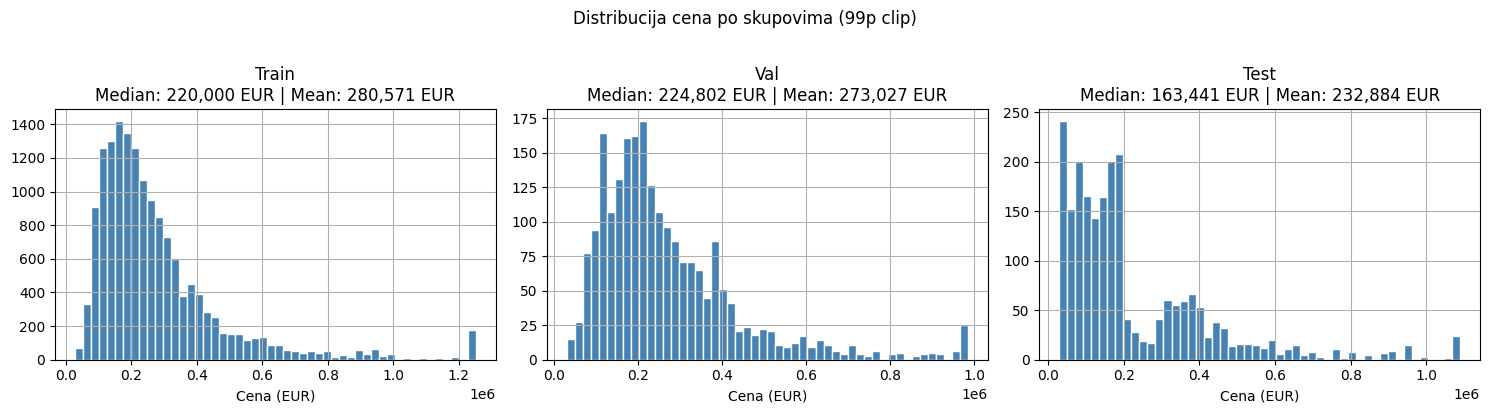

In [12]:
# Distribucija cena po skupovima
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, split) in zip(axes, [("Train", train), ("Val", val), ("Test", test)]):
    clip = split["price_total"].quantile(0.99)
    split["price_total"].clip(upper=clip).hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(
        f"{name}\n"
        f"Median: {split['price_total'].median():,.0f} EUR | "
        f"Mean: {split['price_total'].mean():,.0f} EUR"
    )
    ax.set_xlabel("Cena (EUR)")
plt.suptitle("Distribucija cena po skupovima (99p clip)", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# ── TARGET ENCODING ───────────────────────────────────────────────────────────
encoder = ce.TargetEncoder(cols=["lokacija"])
train["lokacija_encoded"] = encoder.fit_transform(train["lokacija"], train["price_total"])
val["lokacija_encoded"]   = encoder.transform(val["lokacija"])
test["lokacija_encoded"]  = encoder.transform(test["lokacija"])

In [14]:
# ── FEATURE COLS ──────────────────────────────────────────────────────────────
num_cols = [
    "kvadratura", "broj_soba", "sprat", "ukupna_spratnost",
    "sprat_ratio", "amenity_score",
    "mesec_sin", "mesec_cos", "kvartal", "godina",
    "lokacija_encoded",
    "terasa", "parking", "garaza", "lift", "podrum",
    "internet", "klima", "interfon", "video_nadzor", "uknjizen",
]
cat_cols = ["stanje_objekta", "grejanje", "oglasivac", "tip_nekretnine"]
feature_cols = num_cols + cat_cols
 
X_train = train[feature_cols].copy()
X_val   = val[feature_cols].copy()
X_test  = test[feature_cols].copy()
 
Y_train = train["price_total"]
Y_val   = val["price_total"]
Y_test  = test["price_total"]
 
print(f"\nFeatures: {len(feature_cols)} | Train shape: {X_train.shape}")


Features: 25 | Train shape: (15658, 25)


In [15]:
# ── TIPOVI ZA LGBM ────────────────────────────────────────────────────────────
def prep_lgbm(X):
    X = X.copy()
    for col in cat_cols:
        X[col] = X[col].fillna("Unknown").astype("category")
    for col in bool_cols:
        if col in X.columns:
            X[col] = X[col].astype(float)
    X["amenity_score"] = X["amenity_score"].astype(float)
    return X
 
X_train_lgbm = prep_lgbm(X_train)
X_val_lgbm   = prep_lgbm(X_val)
X_test_lgbm  = prep_lgbm(X_test)
 
 
# ── HELPER: evaluacija ─────────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):,.0f} EUR")
    print(f"RMSE: {root_mean_squared_error(y_true, y_pred):,.0f} EUR")
    print(f"R²:   {r2_score(y_true, y_pred):.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 717
[LightGBM] [Info] Number of data points in the train set: 15658, number of used features: 25
[LightGBM] [Info] Start training from score 280570.850875

=== LightGBM bazni — VAL ===
MAE:  42,802 EUR
RMSE: 68,020 EUR
R²:   0.867

=== LightGBM bazni — TEST ===
MAE:  90,108 EUR
RMSE: 149,402 EUR
R²:   0.552

Računam SHAP vrednosti...


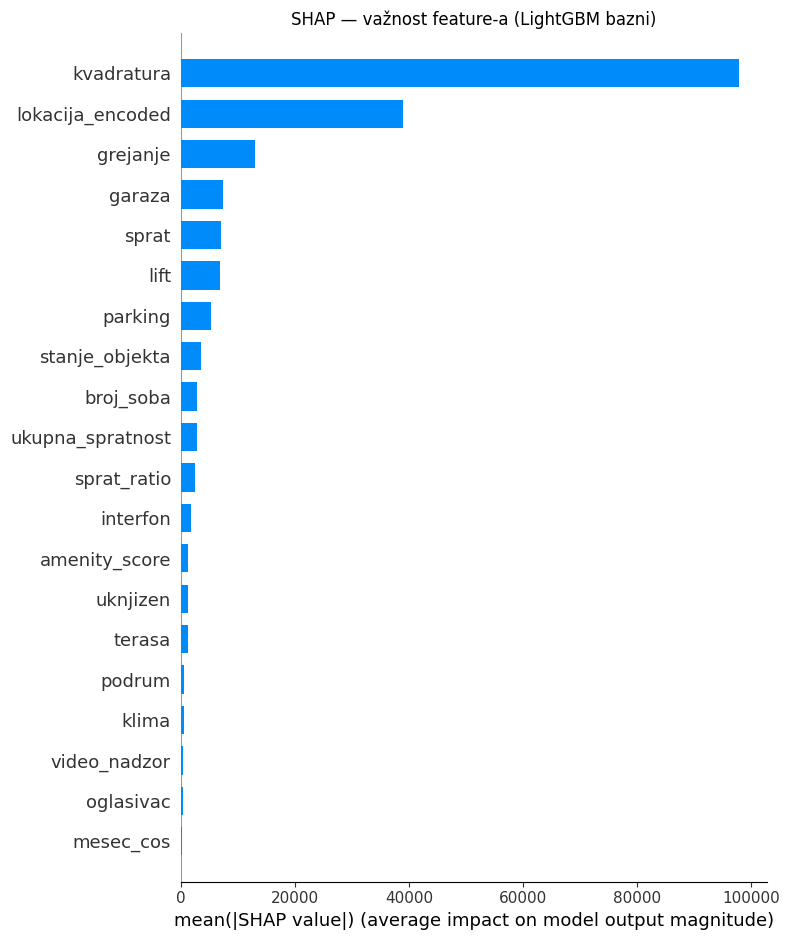

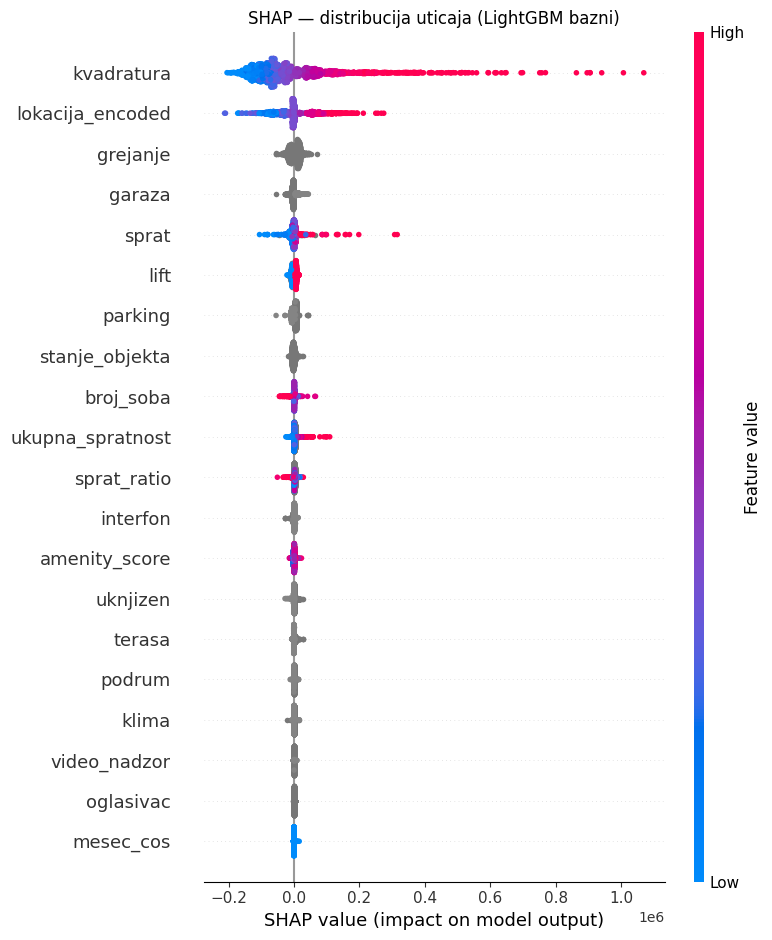

In [16]:
# 1. LIGHTGBM — BAZNI MODEL
# ══════════════════════════════════════════════════════════════════════════════
lgbm_base = lgb.LGBMRegressor(random_state=42, n_jobs=1)
lgbm_base.fit(X_train_lgbm, Y_train)
 
evaluate("LightGBM bazni — VAL",  Y_val,  lgbm_base.predict(X_val_lgbm))
evaluate("LightGBM bazni — TEST", Y_test, lgbm_base.predict(X_test_lgbm))
 
 
# ── SHAP — važnost feature-a ───────────────────────────────────────────────────
print("\nRačunam SHAP vrednosti...")
explainer   = shap.TreeExplainer(lgbm_base)
shap_values = explainer.shap_values(X_val_lgbm)
 
plt.figure()
shap.summary_plot(shap_values, X_val_lgbm, plot_type="bar", show=False)
plt.title("SHAP — važnost feature-a (LightGBM bazni)")
plt.tight_layout()
plt.show()
 
shap.summary_plot(shap_values, X_val_lgbm, show=False)
plt.title("SHAP — distribucija uticaja (LightGBM bazni)")
plt.tight_layout()
plt.show()

In [17]:
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":         trial.suggest_int("max_depth", 3, 7),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": 1,
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train_lgbm, Y_train)
    return mean_absolute_error(Y_val, m.predict(X_val_lgbm))

In [18]:
print("\nOptuna pretraga (50 trials)...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
 
print(f"Najbolji MAE (val): {study.best_value:,.0f} EUR")
print(f"Parametri: {study.best_params}")

[I 2026-05-16 07:05:59,828] A new study created in memory with name: no-name-258b0847-4ff5-4158-97ca-0781b2909879



Optuna pretraga (50 trials)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001233 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 717
[LightGBM] [Info] Number of data points in the train set: 15658, number of used features: 25
[LightGBM] [Info] Start training from score 280570.850875
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

[I 2026-05-16 07:06:00,158] Trial 0 finished with value: 47745.806323618206 and parameters: {'n_estimators': 601, 'max_depth': 3, 'num_leaves': 175, 'learning_rate': 0.0340979785801834, 'min_child_samples': 38, 'subsample': 0.9571180461766691, 'colsample_bytree': 0.6242106847765698}. Best is trial 0 with value: 47745.806323618206.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-16 07:06:00,541] Trial 1 finished with value: 42268.85206706506 and parameters: {'n_estimators': 542, 'max_depth': 6, 'num_leaves': 115, 'learning_rate': 0.1010563868213239, 'min_child_samples': 81, 'subsample': 0.8483683937085396, 'colsample_bytree': 0.8199575898872002}. Best is trial 1 with value: 42268.85206706506.


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 717
[LightGBM] [Info] Number of data points in the train set: 15658, number of used features: 25
[LightGBM] [Info] Start training from score 280570.850875
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

[I 2026-05-16 07:06:34,767] Trial 48 finished with value: 31643.84601803684 and parameters: {'n_estimators': 889, 'max_depth': 7, 'num_leaves': 124, 'learning_rate': 0.08134028948385746, 'min_child_samples': 17, 'subsample': 0.5243012175695762, 'colsample_bytree': 0.9863267399264063}. Best is trial 37 with value: 29949.37014769285.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001619 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 717
[LightGBM] [Info] Number of data points in the train set: 15658, number of used features: 25
[LightGBM] [Info] Start training from score 280570.850875
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

[I 2026-05-16 07:06:35,510] Trial 49 finished with value: 40299.39648908628 and parameters: {'n_estimators': 855, 'max_depth': 7, 'num_leaves': 123, 'learning_rate': 0.04403466028014685, 'min_child_samples': 63, 'subsample': 0.5170357394131764, 'colsample_bytree': 0.9897048760025804}. Best is trial 37 with value: 29949.37014769285.


Najbolji MAE (val): 29,949 EUR
Parametri: {'n_estimators': 927, 'max_depth': 7, 'num_leaves': 102, 'learning_rate': 0.12170340118707618, 'min_child_samples': 18, 'subsample': 0.595634462500574, 'colsample_bytree': 0.7322268704080075}


In [19]:
lgbm_best = lgb.LGBMRegressor(**study.best_params, random_state=42, n_jobs=1)
lgbm_best.fit(X_train_lgbm, Y_train)
 
evaluate("LightGBM optimizovan — VAL",  Y_val,  lgbm_best.predict(X_val_lgbm))
evaluate("LightGBM optimizovan — TEST", Y_test, lgbm_best.predict(X_test_lgbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001315 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 717
[LightGBM] [Info] Number of data points in the train set: 15658, number of used features: 25
[LightGBM] [Info] Start training from score 280570.850875
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/var/folders/8n/t9qxl3yn7615w9l35j5w328m0000gn/T/ipykernel_2060/2840380022.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


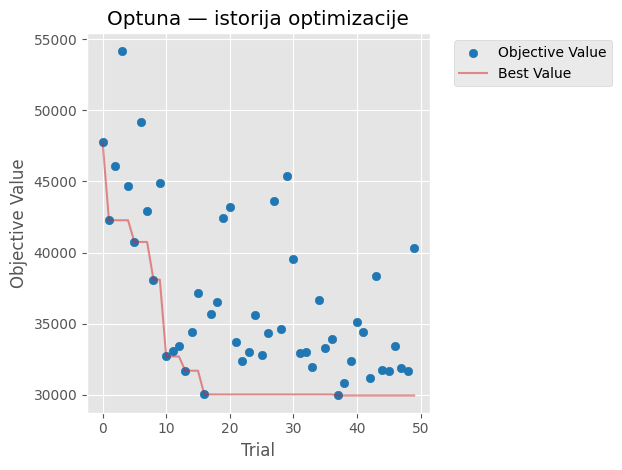

/var/folders/8n/t9qxl3yn7615w9l35j5w328m0000gn/T/ipykernel_2060/2840380022.py:7: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


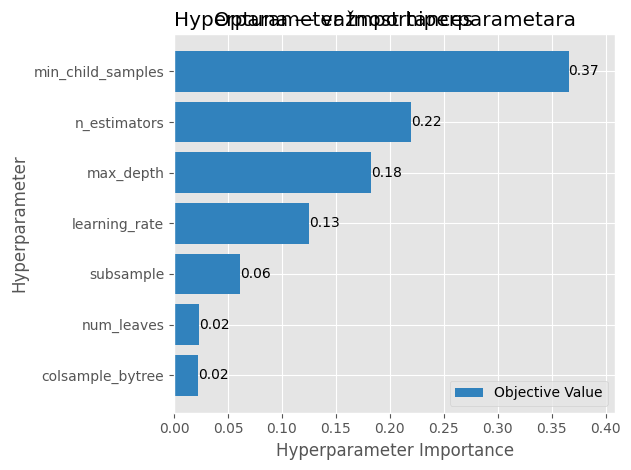

In [20]:
# Optuna vizualizacije
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna — istorija optimizacije")
plt.tight_layout()
plt.show()
 
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Optuna — važnost hiperparametara")
plt.tight_layout()
plt.show()

In [21]:
# 3. CATBOOST
# ══════════════════════════════════════════════════════════════════════════════
# CatBoost prima kategoričke kolone kao string — bez prethodnog enkodiranja
X_train_cat_cb = X_train.copy()
X_val_cat_cb   = X_val.copy()
X_test_cat_cb  = X_test.copy()
 
for col in cat_cols:
    X_train_cat_cb[col] = X_train_cat_cb[col].fillna("Unknown").astype(str)
    X_val_cat_cb[col]   = X_val_cat_cb[col].fillna("Unknown").astype(str)
    X_test_cat_cb[col]  = X_test_cat_cb[col].fillna("Unknown").astype(str)
 
cat_model = CatBoostRegressor(random_state=42, verbose=0, cat_features=cat_cols)
cat_model.fit(X_train_cat_cb, Y_train)
 
evaluate("CatBoost — VAL",  Y_val,  cat_model.predict(X_val_cat_cb))
evaluate("CatBoost — TEST", Y_test, cat_model.predict(X_test_cat_cb))


=== CatBoost — VAL ===
MAE:  41,899 EUR
RMSE: 64,869 EUR
R²:   0.879

=== CatBoost — TEST ===
MAE:  87,934 EUR
RMSE: 147,621 EUR
R²:   0.563


In [22]:
# 4. RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
# RF ne podržava kategoričke kolone direktno — koristimo LabelEncoder
X_train_rf = X_train.copy()
X_val_rf   = X_val.copy()
X_test_rf  = X_test.copy()
 
le = LabelEncoder()
for col in cat_cols:
    # fit samo na train skupu
    X_train_rf[col] = le.fit_transform(X_train_rf[col].fillna("Unknown").astype(str))
    # transform za val i test — kategorije kojih nema u train mapiramo na "Unknown"
    val_vals  = X_val_rf[col].fillna("Unknown").astype(str)
    test_vals = X_test_rf[col].fillna("Unknown").astype(str)
    known     = set(le.classes_)
    X_val_rf[col]  = le.transform(val_vals.where(val_vals.isin(known), "Unknown"))
    X_test_rf[col] = le.transform(test_vals.where(test_vals.isin(known), "Unknown"))
 
for col in bool_cols:
    if col in X_train_rf.columns:
        X_train_rf[col] = X_train_rf[col].astype(float)
        X_val_rf[col]   = X_val_rf[col].astype(float)
        X_test_rf[col]  = X_test_rf[col].astype(float)
 
rf_model = RandomForestRegressor(random_state=42, n_jobs=1)
rf_model.fit(X_train_rf, Y_train)
 
evaluate("Random Forest — VAL",  Y_val,  rf_model.predict(X_val_rf))
evaluate("Random Forest — TEST", Y_test, rf_model.predict(X_test_rf))


=== Random Forest — VAL ===
MAE:  27,338 EUR
RMSE: 57,139 EUR
R²:   0.906

=== Random Forest — TEST ===
MAE:  76,833 EUR
RMSE: 144,459 EUR
R²:   0.581


In [23]:
# ── FINALNA TABELA ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("POREĐENJE SVIH MODELA — TEST SET")
print("=" * 65)
 
results = []
for name, (model, X) in {
    "LightGBM bazni":       (lgbm_base, X_test_lgbm),
    "LightGBM optimizovan": (lgbm_best, X_test_lgbm),
    "CatBoost":             (cat_model, X_test_cat_cb),
    "Random Forest":        (rf_model,  X_test_rf),
}.items():
    y_pred = model.predict(X)
    results.append({
        "Model": name,
        "MAE":   f"{mean_absolute_error(Y_test, y_pred):,.0f} EUR",
        "RMSE":  f"{root_mean_squared_error(Y_test, y_pred):,.0f} EUR",
        "R²":    f"{r2_score(Y_test, y_pred):.3f}",
    })
 
print(pd.DataFrame(results).to_string(index=False))


POREĐENJE SVIH MODELA — TEST SET
               Model        MAE        RMSE    R²
      LightGBM bazni 90,108 EUR 149,402 EUR 0.552
LightGBM optimizovan 79,134 EUR 143,896 EUR 0.585
            CatBoost 87,934 EUR 147,621 EUR 0.563
       Random Forest 76,833 EUR 144,459 EUR 0.581


In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
lin_reg = LinearRegression()
lin_reg.fit(train[['broj_dana']],train['price_total'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
print(f"Koeficijent: {lin_reg.coef_[0]:.2f} EUR/dan")
print(f"Presečište:  {lin_reg.intercept_:,.0f} EUR")

Koeficijent: -220.19 EUR/dan
Presečište:  372,294 EUR


In [27]:
train_pred_lin = lin_reg.predict(train[['broj_dana']])
rezidual_train = train['price_total'] - train_pred_lin

In [28]:
print(f"Prosečan rezidual: {rezidual_train.mean():,.0f} EUR")
print(f"Std reziduala:     {rezidual_train.std():,.0f} EUR")

Prosečan rezidual: 0 EUR
Std reziduala:     219,254 EUR


In [29]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
rf_residual = RandomForestRegressor(random_state = 42, n_jobs = 1)
rf_residual.fit(X_train_rf,rezidual_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
val_pred_lin = lin_reg.predict(val[['broj_dana']])
val_pred_residual = rf_residual.predict(X_val_rf)

val_pred_fin = val_pred_lin + val_pred_residual

evaluate("Hibridni model - VALIDACIONI", Y_val, val_pred_fin)


=== Hibridni model - VALIDACIONI ===
MAE:  27,725 EUR
RMSE: 57,621 EUR
R²:   0.904


In [32]:
# Linearna regresija predviđa trend
test_pred_lin = lin_reg.predict(test[["broj_dana"]])

# RF predviđa rezidual
test_pred_rezidual = rf_residual.predict(X_test_rf)

# Finalna predikcija
test_pred_final = test_pred_lin + test_pred_rezidual

evaluate("Hybrid model — TEST", Y_test, test_pred_final)


=== Hybrid model — TEST ===
MAE:  75,951 EUR
RMSE: 141,239 EUR
R²:   0.600


In [33]:
scale = train['broj_dana'].max()

train['broj_dana_exp'] = np.exp(train['broj_dana']/ scale)
val["broj_dana_exp"]   = np.exp(val["broj_dana"]   / scale)
test["broj_dana_exp"]  = np.exp(test["broj_dana"]  / scale)

lin_reg_exp = LinearRegression()
lin_reg_exp.fit(train[['broj_dana_exp']],train['price_total'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
print(f"Koeficijent: {lin_reg_exp.coef_[0]:.2f} EUR")
print(f"Presečište:  {lin_reg_exp.intercept_:,.0f} EUR")

Koeficijent: -52771.99 EUR
Presečište:  410,397 EUR


In [35]:
X_train_rf_exp = X_train_rf.copy()
X_val_rf_exp   = X_val_rf.copy()
X_test_rf_exp  = X_test_rf.copy()

X_train_rf_exp["broj_dana_exp"] = train["broj_dana_exp"].values
X_val_rf_exp["broj_dana_exp"]   = val["broj_dana_exp"].values
X_test_rf_exp["broj_dana_exp"]  = test["broj_dana_exp"].values

In [36]:
rf_exp = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_exp.fit(X_train_rf_exp, train["price_total"])

evaluate("RF + exp — VAL",  Y_val,  rf_exp.predict(X_val_rf_exp))
evaluate("RF + exp — TEST", Y_test, rf_exp.predict(X_test_rf_exp))


=== RF + exp — VAL ===
MAE:  30,896 EUR
RMSE: 59,323 EUR
R²:   0.898

=== RF + exp — TEST ===
MAE:  79,797 EUR
RMSE: 146,179 EUR
R²:   0.571


In [37]:
from sklearn.preprocessing import PolynomialFeatures

In [38]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_rf[num_cols])
X_val_imp   = imputer.transform(X_val_rf[num_cols])
X_test_imp  = imputer.transform(X_test_rf[num_cols])

In [39]:
poly = PolynomialFeatures()
X_train_poly = poly.fit_transform(X_train_imp)
X_val_poly   = poly.transform(X_val_imp)
X_test_poly  = poly.transform(X_test_imp)

print(f"Originalan broj featurea: {len(num_cols)}")
print(f"Nakon interakcija:        {X_train_poly.shape[1]}")

Originalan broj featurea: 21
Nakon interakcija:        253


In [40]:
rf_poly = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_poly.fit(X_train_poly, Y_train)

evaluate("RF + interakcije — VAL",  Y_val,  rf_poly.predict(X_val_poly))
evaluate("RF + interakcije — TEST", Y_test, rf_poly.predict(X_test_poly))


=== RF + interakcije — VAL ===
MAE:  29,844 EUR
RMSE: 60,110 EUR
R²:   0.896

=== RF + interakcije — TEST ===
MAE:  82,150 EUR
RMSE: 148,005 EUR
R²:   0.560


In [41]:
# Linearna regresija sa interakcijama na numeričkim featurima + broj_dana
poly_lin = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_lin_poly = poly_lin.fit_transform(X_train_imp)
X_val_lin_poly   = poly_lin.transform(X_val_imp)
X_test_lin_poly  = poly_lin.transform(X_test_imp)

lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train_lin_poly, Y_train)

evaluate("LinReg + interakcije — VAL",  Y_val,  lin_reg_poly.predict(X_val_lin_poly))
evaluate("LinReg + interakcije — TEST", Y_test, lin_reg_poly.predict(X_test_lin_poly))


=== LinReg + interakcije — VAL ===
MAE:  56,951 EUR
RMSE: 90,035 EUR
R²:   0.766

=== LinReg + interakcije — TEST ===
MAE:  102,967 EUR
RMSE: 169,829 EUR
R²:   0.421


In [42]:
results = []
for name, (model, X) in {
    "LightGBM bazni":                (lgbm_base,    X_test_lgbm),
    "LightGBM optimizovan":          (lgbm_best,    X_test_lgbm),
    "CatBoost":                      (cat_model,    X_test_cat_cb),
    "Random Forest":                 (rf_model,     X_test_rf),
    "RF + exp":                      (rf_exp,       X_test_rf_exp),
    "RF + interakcije":              (rf_poly,      X_test_poly),
    "LinReg + interakcije":          (lin_reg_poly, X_test_lin_poly),
}.items():
    y_pred = model.predict(X)
    results.append({
        "Model": name,
        "MAE":  f"{mean_absolute_error(Y_test, y_pred):,.0f} EUR",
        "RMSE": f"{root_mean_squared_error(Y_test, y_pred):,.0f} EUR",
        "R²":   f"{r2_score(Y_test, y_pred):.3f}",
    })

# Hibridni model posebno
y_pred_hybrid = lin_reg.predict(test[["broj_dana"]]) + rf_residual.predict(X_test_rf)
results.append({
    "Model": "Hibridni (LinReg + RF)",
    "MAE":  f"{mean_absolute_error(Y_test, y_pred_hybrid):,.0f} EUR",
    "RMSE": f"{root_mean_squared_error(Y_test, y_pred_hybrid):,.0f} EUR",
    "R²":   f"{r2_score(Y_test, y_pred_hybrid):.3f}",
})

print(pd.DataFrame(results).to_string(index=False))

                 Model         MAE        RMSE    R²
        LightGBM bazni  90,108 EUR 149,402 EUR 0.552
  LightGBM optimizovan  79,134 EUR 143,896 EUR 0.585
              CatBoost  87,934 EUR 147,621 EUR 0.563
         Random Forest  76,833 EUR 144,459 EUR 0.581
              RF + exp  79,797 EUR 146,179 EUR 0.571
      RF + interakcije  82,150 EUR 148,005 EUR 0.560
  LinReg + interakcije 102,967 EUR 169,829 EUR 0.421
Hibridni (LinReg + RF)  75,951 EUR 141,239 EUR 0.600


In [43]:
print(len(Y_train), len(Y_test))
print(Y_test.mean())

15658 2236
232884.07066189626


In [44]:
 import joblib

 joblib.dump(lin_reg,      "lin_reg.joblib")
 joblib.dump(rf_residual,  "rf_residual.joblib")
 joblib.dump(le,           "label_encoder.joblib")
 joblib.dump(imputer,      "imputer.joblib")
 joblib.dump(encoder,      "target_encoder.joblib")

 print("Modeli sačuvani.")

Modeli sačuvani.


In [45]:
import os
print(os.getcwd())

/Users/trba/Documents/Projects/Serbia_housing/machine_learning
